In [18]:
# CELL 1: Uninstall conflicting packages first for a clean environment
!pip uninstall -q -y numpy pandas seaborn matplotlib scikit-learn torchcam Pillow torch torchvision

# CELL 2: ML & Deep Learning (install torch/torchvision first, with CUDA 11.8 support)
# Using common stable versions that are compatible with Colab's Python environment
!pip install -q torch==2.3.0 --index-url https://download.pytorch.org/whl/cu118 --no-cache-dir
!pip install -q torchvision==0.18.0 --index-url https://download.pytorch.org/whl/cu118 --no-cache-dir

# CELL 3: Core numerical & data (install compatible, recent versions)
!pip install -q "numpy==2.0.0"      --no-cache-dir
!pip install -q "pandas==2.2.2"      --no-cache-dir
!pip install -q "matplotlib==3.9.0"  --no-cache-dir # Updated to resolve conflict with pointpats
!pip install -q "seaborn==0.13.2"    --no-cache-dir
!pip install -q "Pillow==10.3.0"     --no-cache-dir # Current version should be compatible

# CELL 4: Other ML & Utilities
!pip install -q "scikit-learn==1.6.0" --no-cache-dir # Updated to resolve conflict with umap-learn, cuml-cu12, hdbscan
!pip install -q "tqdm==4.67.0"      --no-cache-dir
!pip install -q "ipywidgets==8.1.2" --no-cache-dir

# CELL 5: Grad-CAM (using torchcam, as 'grad-cam==1.5.0' was not found)
!pip install -q "torchcam==0.4.0" --no-cache-dir

print("Done! Restart runtime now.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 148.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.26 requires torchvision, which is not installed.
sentence-transformers 5.4.1 requires numpy>=1.20.0, which is not installed.
sentence-transformers 5.4.1 requires scikit-learn>=0.22.0, which is not installed.
accelerate 1.13.0 requires numpy>=1.17, which is not installed.
peft 0.19.1 requires numpy>=1.17, which is not installed.
fastai 2.8.7 requires matplotlib, which is not installed.
fastai 2.8.7 requires pandas, which is not installed.
fastai 2.8.7 requires pillow>=9.0.0, which is not installed.
fastai 2.8.7 requires scikit-learn, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
torchtune 0.6.1 requires numpy, which is not installed.
torchtune 0.6.1 requires Pillow>=9.4.0, which is no

In [19]:
!pip install --upgrade numpy pandas seaborn

  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchcam 0.4.0 requires numpy<2.0.0,>=1.17.2, but you have numpy 2.4.4 which is incompatible.
google-colab 1.0.0 requires

In [1]:
# Core imports
import os, tarfile, urllib.request, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

# Sklearn
from sklearn.metrics import confusion_matrix, classification_report

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')

Using device: cpu
PyTorch version: 2.3.0+cu118
Torchvision version: 0.18.0+cu118


In [2]:
import os
import cv2
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style("whitegrid")

In [3]:
import zipfile, shutil

DATA_ROOT = Path('./data/corn_maize_leaf')

def download_corn_maize_kaggle(root: Path):
    root.mkdir(parents=True, exist_ok=True)
    marker = root / '.done_raw'

    if marker.exists():
        print('Raw dataset already prepared.')
        return

    try:
        print('Downloading Corn or Maize Leaf Disease Dataset from Kaggle...')

        # download dataset
        os.system(
            'kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset'
        )

        zip_path = Path('corn-or-maize-leaf-disease-dataset.zip')

        print('Extracting dataset...')
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(root / '_raw')

        raw_path = root / '_raw'

        image_paths = []
        labels = []

        # cari semua gambar dan label
        for class_dir in raw_path.rglob('*'):
            if class_dir.is_dir():

                for img_path in class_dir.glob('*.*'):
                    if img_path.suffix.lower() in [
                        '.png', '.jpg', '.jpeg'
                    ]:
                        image_paths.append(img_path)
                        labels.append(class_dir.name.lower())

        # ambil semua class unik
        target_classes = sorted(set(labels))

        print(f"Detected classes: {target_classes}")

        # filter data valid
        data = [
            (p, l)
            for p, l in zip(image_paths, labels)
            if l in target_classes
        ]

        # buat folder raw
        raw_clean = root / 'raw'

        for cls in target_classes:
            (raw_clean / cls).mkdir(parents=True, exist_ok=True)

        # copy dan rename file
        for i, (src, label) in enumerate(
            tqdm(data, desc='Organizing RAW')
        ):
            dst = raw_clean / label / f'{i:05d}{src.suffix}'
            shutil.copy(src, dst)

        marker.touch()

        print(f'\nRAW dataset ready!')
        print(f'Total classes: {len(target_classes)}')

    except Exception as e:
        print(f'Error: {e}')
        print('Pastikan Kaggle API sudah dikonfigurasi!')


# RUN
download_corn_maize_kaggle(DATA_ROOT)

# VERIFY
data_dir = DATA_ROOT / 'raw'

classes = sorted([
    d.name for d in data_dir.iterdir()
    if d.is_dir()
])

print(f"\nClasses ({len(classes)}): {classes}")

n_total = sum(
    len(list((data_dir / c).glob('*.*')))
    for c in classes
)

print(f"Total images: {n_total}")

Raw dataset already prepared.

Classes (4): ['blight', 'common_rust', 'gray_leaf_spot', 'healthy']
Total images: 4188


# ASPEK DATA

In [4]:
records = []

for label in os.listdir(data_dir):
    label_path = os.path.join(data_dir, label)

    if os.path.isdir(label_path):

        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)

            try:
                img = Image.open(img_path)
                arr = np.array(img)

                width, height = img.size
                channels = arr.shape[2] if len(arr.shape) == 3 else 1
                img_size = os.path.getsize(img_path) / 1024  # KB

                records.append({
                    "filename": img_name,
                    "label": label,
                    "width": width,
                    "height": height,
                    "channels": channels,
                    "file_size_kb": img_size
                })

            except:
                records.append({
                    "filename": img_name,
                    "label": label,
                    "width": np.nan,
                    "height": np.nan,
                    "channels": np.nan,
                    "file_size_kb": np.nan
                })

df = pd.DataFrame(records)

print(df.head())
print(df.shape)

    filename    label  width  height  channels  file_size_kb
0  03263.jpg  healthy    256     256         3     12.127930
1  03629.jpg  healthy    256     256         3      6.072266
2  03636.jpg  healthy    256     256         3      7.774414
3  03705.jpg  healthy    256     256         3      8.301758
4  03898.jpg  healthy    256     256         3      4.875977
(4188, 6)


In [5]:
df.describe()

,width,height,channels,file_size_kb
count,4188.000000,4188.000000,4188.000000,4188.000000
mean,307.536533,297.906160,3.001194,39.915494
std,285.716933,253.138674,0.034536,227.460337
min,180.000000,116.000000,3.000000,3.783203
25%,256.000000,256.000000,3.000000,11.618164
50%,256.000000,256.000000,3.000000,13.691895
75%,256.000000,256.000000,3.000000,15.799805
max,5184.000000,5184.000000,4.000000,6419.989258


In [6]:
attribute_desc = pd.DataFrame({
    "Attribute": df.columns,
    "Description": [
        "Nama file gambar",
        "Kategori penyakit jagung",
        "Lebar gambar (pixel)",
        "Tinggi gambar (pixel)",
        "Jumlah channel warna",
        "Ukuran file gambar (KB)"
    ],
    "Data Type": df.dtypes.values
})

attribute_desc

,Attribute,Description,Data Type
0,filename,Nama file gambar,str
1,label,Kategori penyakit jagung,str
2,width,Lebar gambar (pixel),int64
3,height,Tinggi gambar (pixel),int64
4,channels,Jumlah channel warna,int64
5,file_size_kb,Ukuran file gambar (KB),float64


label
common_rust       1306
healthy           1162
blight            1146
gray_leaf_spot     574
Name: count, dtype: int64


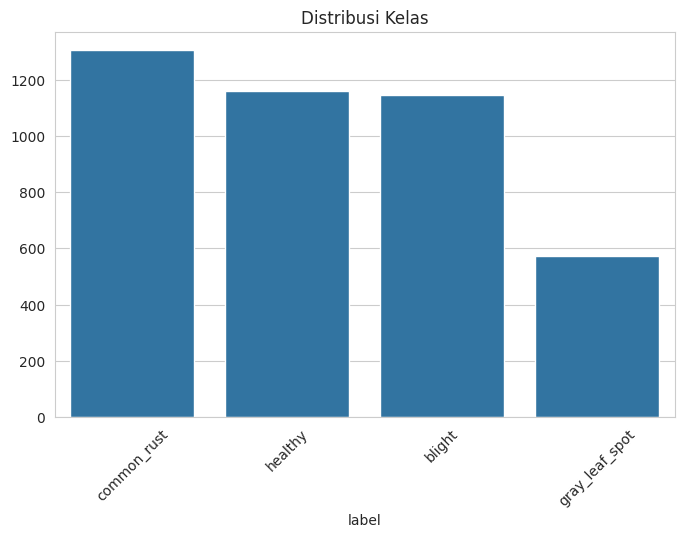

In [7]:
#cek pesebaran data
class_counts = df["label"].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.xticks(rotation=45)
plt.title("Distribusi Kelas")
plt.show()

In [8]:
imbalance_ratio = class_counts.max() / class_counts.min()

print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 2.275261324041812


In [9]:
min_class = class_counts.min()

ratio = (class_counts / min_class).round(2)

print(ratio)

label
common_rust       2.28
healthy           2.02
blight            2.00
gray_leaf_spot    1.00
Name: count, dtype: float64


In [10]:
#sparsity
def calc_sparsity(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    total_pixels = img.size
    zero_pixels = np.sum(img == 0)

    return (zero_pixels / total_pixels) * 100

In [11]:
sample_paths = []

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)

    imgs = os.listdir(folder)[:100]

    for img in imgs:
        sample_paths.append(os.path.join(folder, img))

sparsity_scores = [calc_sparsity(p) for p in sample_paths]

print("Average Sparsity:", np.mean(sparsity_scores), "%")

Average Sparsity: 4.664823710472924 %


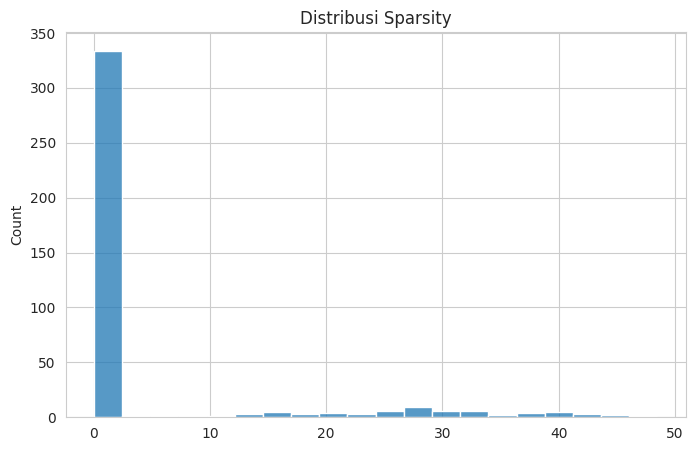

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(sparsity_scores, bins=20)
plt.title("Distribusi Sparsity")
plt.show()

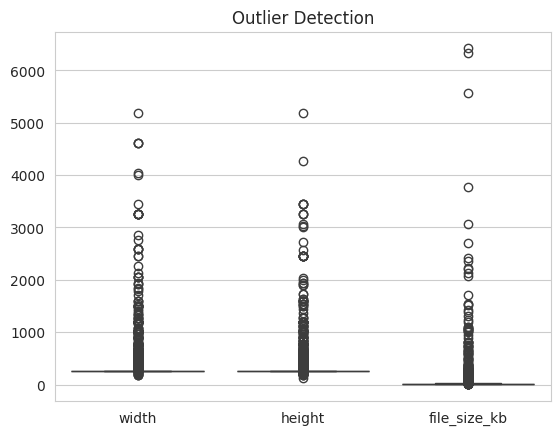

In [13]:
sns.boxplot(data=df[["width", "height", "file_size_kb"]])
plt.title("Outlier Detection")
plt.show()

In [14]:
def outlier_count(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    return len(outliers)

for col in ["width", "height", "file_size_kb"]:
    print(col, ":", outlier_count(col))

width : 335
height : 336
file_size_kb : 332


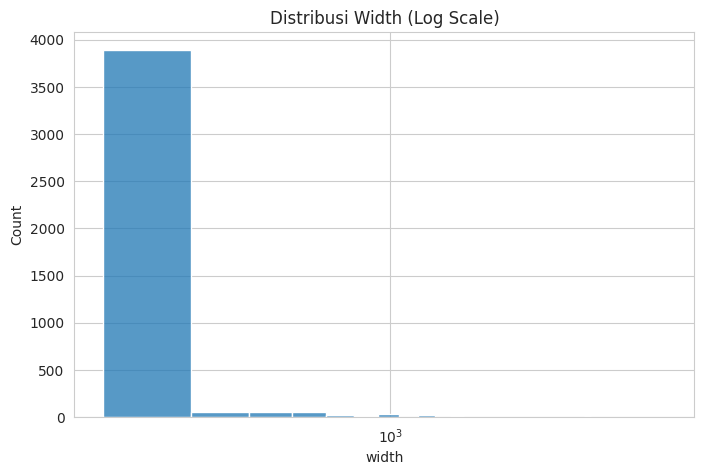

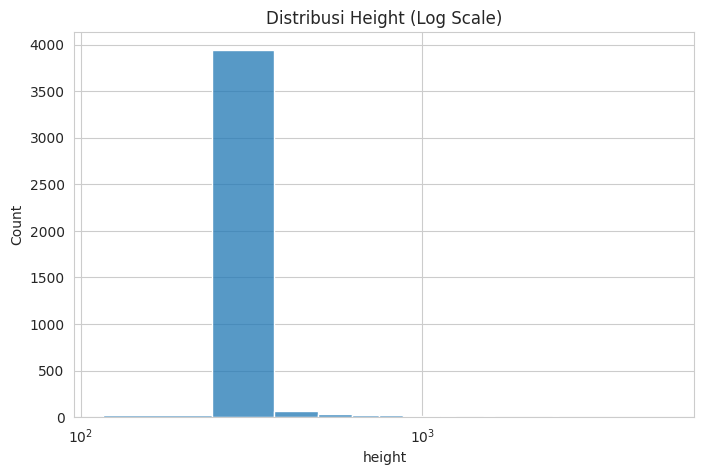

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["width"], bins=40)

plt.xscale("log")
plt.title("Distribusi Width (Log Scale)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["height"], bins=40)

plt.xscale("log")
plt.title("Distribusi Height (Log Scale)")
plt.show()

In [16]:
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = []

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)

    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)
        hashes.append(file_hash(path))

duplicates = len(hashes) - len(set(hashes))

print("Duplicate images:", duplicates)

Duplicate images: 2


In [17]:

corrupt_images = []

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()   # cek file valid
        except:
            corrupt_images.append(img_path)

print("Jumlah corrupt/missing images:", len(corrupt_images))

Jumlah corrupt/missing images: 0


# Data Eksploration

In [18]:
class_dropdown = widgets.Dropdown(
    options=classes,
    description='Class:',
    style={'description_width': 'initial'}
)

n_images_slider = widgets.IntSlider(
    value=6, min=2, max=16, step=2,
    description='# Images:',
    style={'description_width': 'initial'}
)

def show_class_samples(class_name, n_images):
    cls_dir = data_dir / class_name

    imgs = [p for p in cls_dir.rglob('*')
            if p.suffix.lower() in ['.png','.jpg','.jpeg', 'Other']][:n_images]

    if len(imgs) == 0:
        print("No images found!")
        return

    fig, axes = plt.subplots(1, len(imgs), figsize=(3 * len(imgs), 3))

    if len(imgs) == 1:
        axes = [axes]

    fig.suptitle(f'Class: {class_name} (RAW DATA)', fontsize=14, weight='bold')

    for ax, img_path in zip(axes, imgs):
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'{img.size[0]}×{img.size[1]}', fontsize=8)

    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(
    show_class_samples,
    {'class_name': class_dropdown, 'n_images': n_images_slider}
)

display(widgets.HBox([class_dropdown, n_images_slider]), out)

Output()

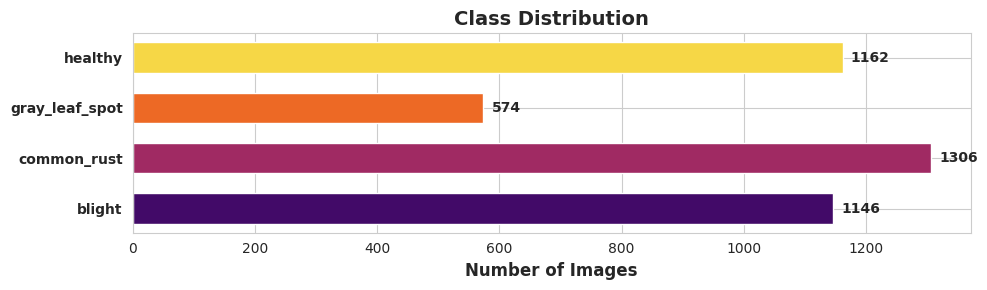

In [19]:
counts = {
    cls: len(list((data_dir / cls).glob('*.*')))
    for cls in classes
}

labels = list(counts.keys())
values = list(counts.values())

# warna bar chart
colors = plt.cm.inferno(np.linspace(0.2, 0.9, len(labels)))

y_pos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 3))

bars = ax.barh(y_pos, values, color=colors, height=0.6)

# Set label posisi Y
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontweight='bold')

# Judul & label
ax.set_xlabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')

# Angka di samping bar
for i, v in enumerate(values):
    ax.text(
        v + max(values)*0.01,
        i,
        str(v),
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [20]:
def analyze_image_quality_raw(data_dir, classes, sample_per_class=50):
    results = {}

    for cls in classes:
        cls_dir = data_dir / cls

        # ambil semua citra
        img_paths = [
            p for p in cls_dir.rglob('*')
            if p.suffix.lower() in ['.png', '.jpg', '.jpeg', 'Other']
        ][:sample_per_class]

        brightness = []
        contrast = []
        sizes = []

        for img_path in img_paths:
            try:
                img = Image.open(img_path).convert('L')
                img_np = np.array(img)

                brightness.append(np.mean(img_np))
                contrast.append(np.std(img_np))
                sizes.append(img.size)

            except:
                continue

        # hitung statistik
        results[cls] = {
            'brightness_mean': np.mean(brightness) if brightness else 0,
            'brightness_std': np.std(brightness) if brightness else 0,

            'contrast_mean': np.mean(contrast) if contrast else 0,
            'contrast_std': np.std(contrast) if contrast else 0,

            'avg_size': np.mean(sizes, axis=0) if sizes else (0, 0)
        }

    return results


# RUN
quality_results = analyze_image_quality_raw(data_dir, classes)

# PRINT HASIL
for cls, vals in quality_results.items():
    print(f"\nClass: {cls}")
    print(f"Brightness  : {vals['brightness_mean']:.2f} ± {vals['brightness_std']:.2f}")
    print(f"Contrast    : {vals['contrast_mean']:.2f} ± {vals['contrast_std']:.2f}")
    print(f"Avg Size    : {vals['avg_size']}")


Class: blight
Brightness  : 118.45 ± 7.72
Contrast    : 33.65 ± 9.03
Avg Size    : [327.6 324.4]

Class: common_rust
Brightness  : 90.98 ± 17.35
Contrast    : 63.87 ± 10.08
Avg Size    : [293.12 291.84]

Class: gray_leaf_spot
Brightness  : 117.83 ± 15.35
Contrast    : 37.90 ± 10.08
Avg Size    : [290.64 270.74]

Class: healthy
Brightness  : 148.15 ± 20.04
Contrast    : 33.20 ± 10.09
Avg Size    : [256. 256.]
